In [2]:
# =========================
# 0) Imports & Setup
# =========================
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(context="notebook", style="whitegrid")

from IPython.display import display

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [4]:
# =========================
# 1) Load & Basic EDA (df1 only)
# =========================
# Load once; keep df1 as your single working table
data_frame = pd.read_csv("data.csv")

# If your CSV already has the needed columns, keep them; otherwise, grab what's present.
cols_wanted = ["Name", "Age", "Overall", "Potential", "International Reputation", "Skill Moves", "Wage", "Value"]
present_cols = [c for c in cols_wanted if c in data_frame.columns]
df1 = data_frame[present_cols].copy()

print("df1 shape:", df1.shape)
display(df1.head())
display(df1.describe(include="all").T.head(12))


df1 shape: (18207, 8)


,Name,Age,Overall,Potential,International Reputation,Skill Moves,Wage,Value
0,L. Messi,31,94,94,5.0,4.0,€565K,€110.5M
1,Cristiano Ronaldo,33,94,94,5.0,5.0,€405K,€77M
2,Neymar Jr,26,92,93,5.0,5.0,€290K,€118.5M
3,De Gea,27,91,93,4.0,1.0,€260K,€72M
4,K. De Bruyne,27,91,92,4.0,4.0,€355K,€102M


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,18207,17194,J. Rodríguez,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,18207.0,NaN,NaN,NaN,25.122206,4.669943,16.0,21.0,25.0,28.0,45.0
Overall,18207.0,NaN,NaN,NaN,66.238699,6.90893,46.0,62.0,66.0,71.0,94.0
Potential,18207.0,NaN,NaN,NaN,71.307299,6.136496,48.0,67.0,71.0,75.0,95.0
International Reputation,18159.0,NaN,NaN,NaN,1.113222,0.394031,1.0,1.0,1.0,1.0,5.0
Skill Moves,18159.0,NaN,NaN,NaN,2.361308,0.756164,1.0,2.0,2.0,3.0,5.0
Wage,18207,144,€1K,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,18207,217,€1.1M,431,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# =========================
# 2) Cleaning currency strings in-place (df1)
# =========================
# Robust parser for forms like "€1.2M", "$850K", "1000", etc.
money_re = re.compile(r'^\s*([€$])?\s*([\d]+(?:\.\d+)?)\s*([KMB])?\s*$')

def parse_money(x):
    if pd.isna(x): 
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x)
    m = money_re.match(s.replace(",", ""))
    if not m:
        return np.nan
    _, num, suffix = m.groups()
    num = float(num)
    mult = {"K": 1_000, "M": 1_000_000, "B": 1_000_000_000}.get(suffix, 1)
    return num * mult

for col in ["Wage", "Value"]:
    if col in df1.columns:
        df1[col] = (df1[col]
                    .astype(str)
                    .str.replace(r"[€$,]", "", regex=True)
                    .str.strip()
                    .apply(parse_money))

# Basic validity filtering: drop rows without Wage/Value or with non-positive values
if {"Wage","Value"}.issubset(df1.columns):
    before = len(df1)
    df1 = df1.dropna(subset=["Wage","Value"])
    df1 = df1[(df1["Wage"] > 0) & (df1["Value"] > 0)]
    after = len(df1)
    print(f"Kept {after}/{before} rows after cleaning Wage/Value.")
else:
    print("Warning: Wage/Value not both present; later steps will skip related parts.")

# Replace inf/-inf if any
df1 = df1.replace([np.inf, -np.inf], np.nan)

display(df1.sample(min(5, len(df1)), random_state=42))


Kept 17955/18207 rows after cleaning Wage/Value.


,Name,Age,Overall,Potential,International Reputation,Skill Moves,Wage,Value
17574,A. Estrada,19,53,65,1.0,2.0,1000.0,100000.0
9510,D. Peitz,33,66,66,1.0,2.0,4000.0,260000.0
15325,C. Hall,20,59,74,1.0,2.0,2000.0,350000.0
1566,M. Antonio,28,76,76,2.0,4.0,69000.0,8000000.0
11255,J. Allansson,25,64,67,1.0,3.0,3000.0,550000.0


In [8]:
# =========================
# 3) Feature Engineering (in-place on df1)
# =========================
# Helpful ratios and transforms for modeling & clustering
if {"Wage","Value"}.issubset(df1.columns):
    df1["Value_to_Wage"]   = df1["Value"] / df1["Wage"]
    df1["Value_minus_Wage"] = df1["Value"] - df1["Wage"]
    # Log transforms help with heavy skew
    df1["log_Wage"]  = np.log1p(df1["Wage"])
    df1["log_Value"] = np.log1p(df1["Value"])

# Optional non-linear term
if "Age" in df1.columns:
    df1["Age_sq"] = df1["Age"]**2

display(df1.describe().T.loc[["Wage","Value","Value_to_Wage","log_Wage","log_Value","Age","Age_sq"], 
                             ["count","mean","std","min","50%","max"]].dropna(how="all"))


,count,mean,std,min,50%,max
Wage,17955.0,9.865831e+03,2.212314e+04,1000.000000,3000.000000,5.650000e+05
Value,17955.0,2.444530e+06,5.626715e+06,10000.000000,700000.000000,1.185000e+08
Value_to_Wage,17955.0,3.336368e+02,7.571095e+02,5.000000,212.500000,2.100000e+04
log_Wage,17955.0,8.276459e+00,1.230932e+00,6.908755,8.006701,1.324458e+01
log_Value,17955.0,1.362040e+01,1.406162e+00,9.210440,13.458837,1.859042e+01
Age,17955.0,2.509535e+01,4.659778e+00,16.000000,25.000000,4.500000e+01
Age_sq,17955.0,6.514889e+02,2.434477e+02,256.000000,625.000000,2.025000e+03


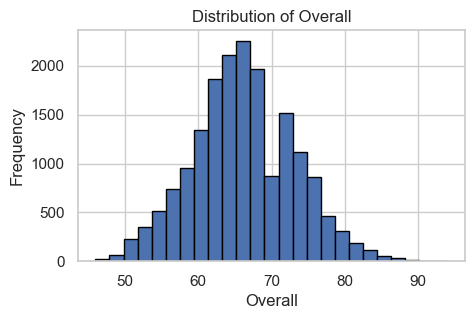

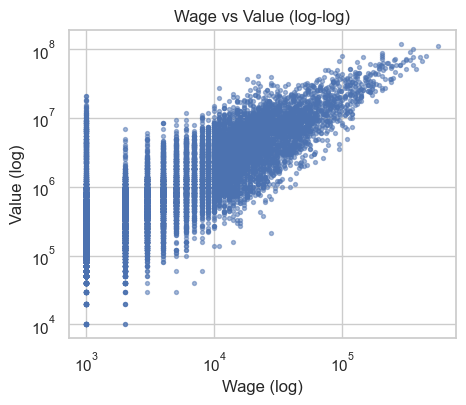

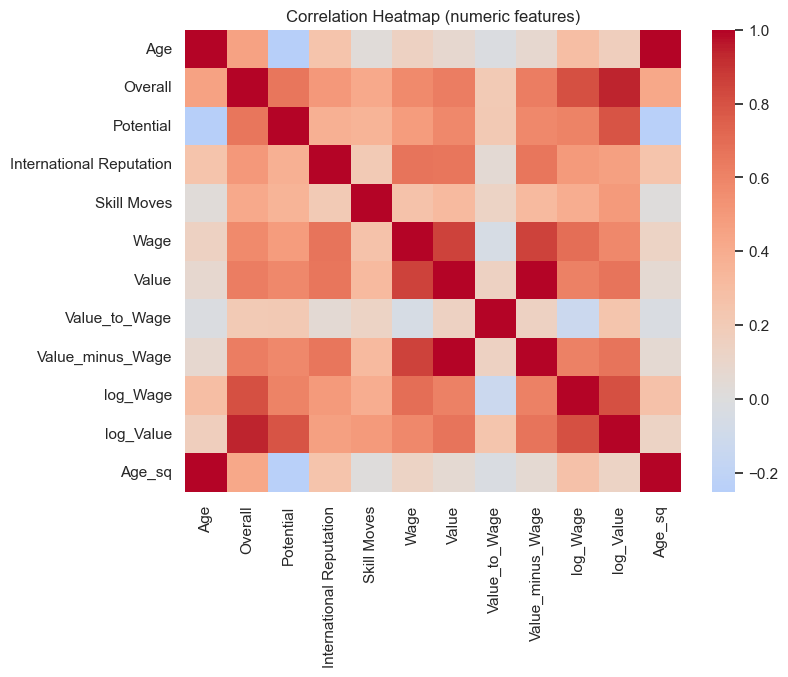

In [10]:
# =========================
# 4) Visualization (static): distributions & relationships
# =========================
plt.figure(figsize=(5,3))
if "Overall" in df1.columns:
    df1["Overall"].plot(kind="hist", bins=25, edgecolor="black", title="Distribution of Overall")
    plt.xlabel("Overall")
    plt.show()

if {"Wage","Value"}.issubset(df1.columns):
    plt.figure(figsize=(5,4))
    plt.scatter(df1["Wage"], df1["Value"], s=8, alpha=0.5)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Wage (log)"); plt.ylabel("Value (log)")
    plt.title("Wage vs Value (log-log)")
    plt.show()

# Correlation heatmap for numeric columns
num_cols = df1.select_dtypes(include=np.number).columns
plt.figure(figsize=(8,6))
sns.heatmap(df1[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.show()


Ridge  R²=0.976 | MAE=544,014
RF     R²=0.993    | MAE=194,737


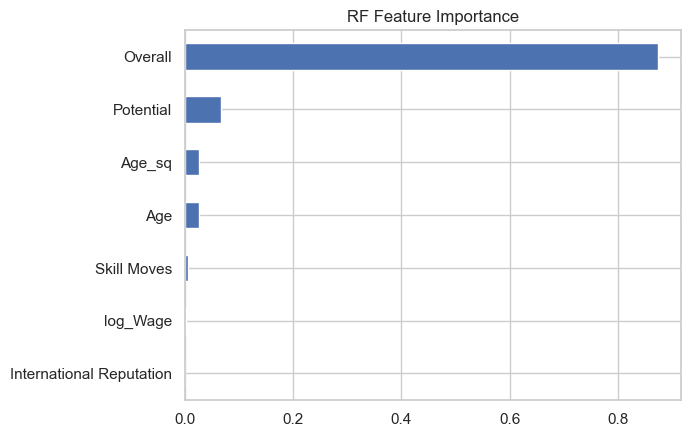

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidate_features = ["Age","Age_sq","Overall","Potential","International Reputation","Skill Moves","log_Wage"]
X_cols = [c for c in candidate_features if c in df1.columns]

# Keep rows where y is not NaN; allow NaNs in X (we'll impute)
mask = df1["log_Value"].notna()
X = df1.loc[mask, X_cols]
y = df1.loc[mask, "log_Value"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, X_cols)],
    remainder="drop"
)

ridge_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Ridge  R²={r2_score(y_test, y_pred_ridge):.3f} | MAE={mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_ridge)):,.0f}")
print(f"RF     R²={r2_score(y_test, y_pred_rf):.3f}    | MAE={mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf)):,.0f}")

# Get RF feature importances (requires a small trick to read from pipeline)
rf = rf_model.named_steps["model"]
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values()
imp.plot(kind="barh", title="RF Feature Importance"); plt.show()

# Attach predictions/residuals back in native Value units (optional)
pred_log_test = pd.Series(y_pred_rf, index=X_test.index, name="pred_log_Value_rf")
df1 = df1.join(pred_log_test, how="left")
df1["pred_Value_rf"] = np.expm1(df1["pred_log_Value_rf"])
df1["residual_Value_rf"] = df1["pred_Value_rf"] - df1["Value"]


Chosen k = 5 (silhouette = 0.374) on 17955 players with features ['Age', 'Overall', 'Wage', 'Value', 'Value_to_Wage']


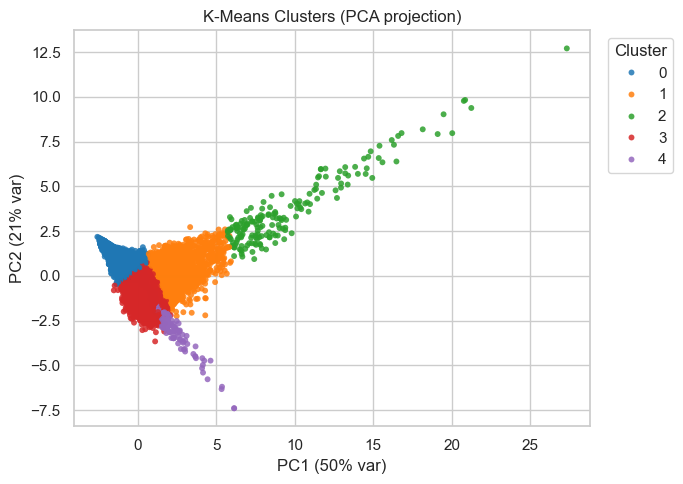

,cluster,Age,Overall,Wage,Value,Value_to_Wage
0,0,21.04,60.93,2665.92,568261.96,260.70
1,1,26.07,76.39,34472.45,9364477.74,352.85
2,2,26.90,85.32,167105.56,41647222.22,273.34
3,3,28.66,67.79,6211.15,1255360.43,272.94
4,4,26.45,75.40,1000.00,7472661.87,7472.66


Age                 Overall                        Wage  \
              mean median count       mean median count           mean   
cluster                                                                  
0.0      21.040042   21.0  7542  60.928666   61.0  7542    2665.605940   
1.0      26.068433   26.0  2265  76.391611   76.0  2265   34502.428256   
2.0      26.900000   27.0   180  85.322222   85.0   180  167105.555556   
3.0      28.654873   28.0  7829  67.791417   68.0  7829    6216.758207   
4.0      26.453237   27.0   139  75.395683   75.0   139    1000.000000   

                                Value                   Value_to_Wage  \
           median count          mean      median count          mean   
cluster                                                                 
0.0        2000.0  7542  5.679793e+05    400000.0  7542    260.663363   
1.0       29000.0  2265  9.372804e+06   8000000.0  2265    352.888182   
2.0      140000.0   180  4.164722e+07  36500000.0   180    273.340627   
3.0        4000.0  7829  1.257279e+06    800000.0  7829    273.002102   
4.0        1000.0   139  7.472662e+06   6500000.0   139   7472.661871   

                            
              median count  
cluster                     
0.0       200.000000  7542  
1.0       278.688525  2265  
2.0       245.307918   180  
3.0       200.000000  7829  
4.0      6500.000000   139

,Name,Age,Overall,Wage,Value,Value_to_Wage,cluster_label
0,L. Messi,31,94,565000.0,110500000.0,195.575221,C2: Elite Veterans
1,Cristiano Ronaldo,33,94,405000.0,77000000.0,190.123457,C2: Elite Veterans
2,Neymar Jr,26,92,290000.0,118500000.0,408.620690,C2: Elite Veterans
3,De Gea,27,91,260000.0,72000000.0,276.923077,C2: Elite Veterans
4,K. De Bruyne,27,91,355000.0,102000000.0,287.323944,C2: Elite Veterans
5,E. Hazard,27,91,340000.0,93000000.0,273.529412,C2: Elite Veterans
6,L. Modrić,32,91,420000.0,67000000.0,159.523810,C2: Elite Veterans
7,L. Suárez,31,91,455000.0,80000000.0,175.824176,C2: Elite Veterans
8,Sergio Ramos,32,91,380000.0,51000000.0,134.210526,C2: Elite Veterans
9,J. Oblak,25,90,94000.0,68000000.0,723.404255,C2: Elite Veterans


In [21]:
# =========================
# 6) Clustering: K-Means + PCA on df1
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- A) Pick clustering features (use what exists in your csv)
cluster_candidates = ["Age", "Overall", "Wage", "Value", "Value_to_Wage"]
X_cols = [c for c in cluster_candidates if c in df1.columns]
assert len(X_cols) >= 3, f"Need ≥3 clustering features. Found: {X_cols}"

# ---- B) Build the matrix Z with valid rows only
Z = df1[X_cols].copy()
Z = Z.replace([np.inf, -np.inf], np.nan).dropna()
idx_valid = Z.index  # remember which rows survive cleaning

# ---- C) Scale (critical for K-Means) 
scaler = StandardScaler()
Zs = scaler.fit_transform(Z)

# ---- D) Choose k by silhouette (3..7)
best_k, best_score = None, -1
for k in range(3, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(Zs)
    score = silhouette_score(Zs, labels)
    if score > best_score:
        best_k, best_score = k, score

print(f"Chosen k = {best_k} (silhouette = {best_score:.3f}) on {Zs.shape[0]} players with features {X_cols}")

# ---- E) Final K-Means with best k
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
labels = kmeans.fit_predict(Zs)

# Attach labels back to df1 (NaN for rows not used)
df1.loc[:, "cluster"] = np.nan
df1.loc[idx_valid, "cluster"] = labels

# ---- F) PCA for 2D visualization (pretty scatter)
pca = PCA(n_components=2, random_state=42)
Zp = pca.fit_transform(Zs)

plt.figure(figsize=(7,5))
sns.scatterplot(x=Zp[:,0], y=Zp[:,1], hue=labels, palette="tab10", s=18, alpha=0.85, edgecolor="none")
plt.title("K-Means Clusters (PCA projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- G) Cluster centroids (in original units)
centroids_scaled = kmeans.cluster_centers_                 # in z-score space
centroids_orig = scaler.inverse_transform(centroids_scaled) # back to original units
centroids = pd.DataFrame(centroids_orig, columns=X_cols)
centroids.insert(0, "cluster", range(best_k))
display(centroids.round(2))

# ---- H) Cluster profiles: mean/median/count per cluster
profile = (df1.loc[idx_valid, ["cluster"] + X_cols]
             .groupby("cluster")
             .agg(["mean","median","count"]))
display(profile)

# ---- I) Optional: quick human-readable cluster labels (edit heuristics as you like)
# Example heuristic using means from centroids:
labels_map = {}
if {"Overall", "Age", "Value_to_Wage"}.issubset(centroids.columns):
    for r in centroids.itertuples(index=False):
        name = f"C{int(r.cluster)}"
        if r.Overall >= centroids["Overall"].median() and r.Age <= centroids["Age"].median():
            name = f"{name}: Young High-Overall"
        elif r.Overall >= centroids["Overall"].median() and r.Age > centroids["Age"].median():
            name = f"{name}: Elite Veterans"
        elif r.Value_to_Wage >= centroids["Value_to_Wage"].median():
            name = f"{name}: Efficient Contracts"
        else:
            name = f"{name}: Developing/Overpaid"
        labels_map[int(r.cluster)] = name

    # create readable label column
    df1.loc[idx_valid, "cluster_label"] = df1.loc[idx_valid, "cluster"].astype(int).map(labels_map)
    display(df1.loc[idx_valid, ["Name","Age","Overall","Wage","Value","Value_to_Wage","cluster_label"]].head(10))
else:
    print("Skipped label heuristics (need Overall, Age, Value_to_Wage).")
